# SeqOptPlot.genealogy - mutational lineage of the designed variants\n\nThe directed-evolution analogue of a genealogy tree: each variant is placed by its number of mutations (depth) and linked to the lower-order variant it extends, rooted at the wild-type (WT) and colored by predicted substrate gain - showing how the super substrate is built up mutation by mutation.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import aaanalysis as aa
aa.options["verbose"] = False
df_feat = aa.load_features(name="DOM_GSEC"); df_seq = aa.load_dataset(name="DOM_GSEC", n=50)
labels = df_seq["label"].to_list(); sf = aa.SequenceFeature()
X = np.asarray(sf.feature_matrix(features=df_feat["feature"], df_parts=sf.get_df_parts(df_seq=df_seq), df_scales=aa.load_scales()), float)
model = RandomForestClassifier(n_estimators=100, random_state=0).fit(X, labels)
wt = df_seq[df_seq["label"] == 0].iloc[[0]].reset_index(drop=True)
objectives = [("substrate", "max", "delta_pred"), ("parsimony", "min", "n_mut")]
seqopt = aa.SeqOpt(mode="importance", model=model, target_class=1, random_state=42)
df_pareto = seqopt.run(df_seq=wt, df_feat=df_feat, objectives=objectives, pop_size=40, n_gen=20, n_mut_max=6, region="tmd")
aa.display_df(df_pareto, n_rows=10, show_shape=True)

DataFrame shape: (5, 8)


,entry,variant,n_mut,sequence_mut,substrate,parsimony,rank,crowding
1,Q14802,,0,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0.000000,0.000000,0,inf
2,Q14802,C49V+I55R+S58R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,27.000000,3.000000,0,inf
3,Q14802,C49L+I55R+S58R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,27.000000,3.000000,0,inf
4,Q14802,S58R,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,14.000000,1.000000,0,0.796296
5,Q14802,C49M+S58R,2,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,25.000000,2.000000,0,0.574074


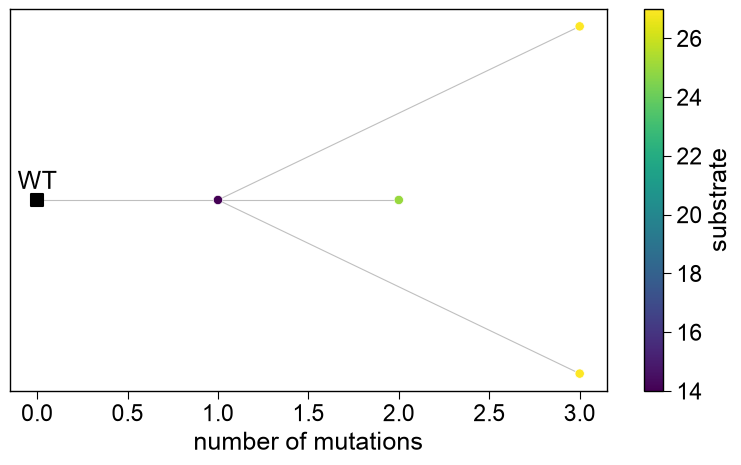

In [2]:
aa.plot_settings()
aa.SeqOptPlot().genealogy(df_pareto=df_pareto, front_only=False)
plt.tight_layout(); plt.show()